In [ ]:
import sys
from packaging import version

import numpy as np
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

assert sys.version_info >= (3, 7) # assert that Python version is greater than 3.7
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
pd.set_option('display.max_columns', None)
sns.set_style(style="whitegrid")

**Goals:**
1. Predict the temperature change per year given features in data - evaluate results using RMSE and $R^2$ (with MAE for comparision)
2. Identify the most important features and sources of carbon emissions

# Data Acquisition

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("alessandrolobello/agri-food-co2-emission-dataset-forecasting-ml")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'agri-food-co2-emission-dataset-forecasting-ml' dataset.
Path to dataset files: /kaggle/input/agri-food-co2-emission-dataset-forecasting-ml


In [ ]:
file_path = os.path.join(path, "Agrofood_co2_emission.csv")
agrifood_dataset = pd.read_csv(file_path)

## First Look at Data

In [ ]:
agrifood_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Area                             6965 non-null   object 
 1   Year                             6965 non-null   int64  
 2   Savanna fires                    6934 non-null   float64
 3   Forest fires                     6872 non-null   float64
 4   Crop Residues                    5576 non-null   float64
 5   Rice Cultivation                 6965 non-null   float64
 6   Drained organic soils (CO2)      6965 non-null   float64
 7   Pesticides Manufacturing         6965 non-null   float64
 8   Food Transport                   6965 non-null   float64
 9   Forestland                       6472 non-null   float64
 10  Net Forest conversion            6472 non-null   float64
 11  Food Household Consumption       6492 non-null   float64
 12  Food Retail         

In [ ]:
agrifood_dataset.head(n=3)

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.00,0.0,11.807483,63.1152,-2388.803,0.0,79.0851,109.6446,14.2666,67.631366,691.7888,252.21419,11.9970,209.9778,260.1431,1590.5319,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,209.4971,678.16,0.0,11.712073,61.2125,-2388.803,0.0,80.4885,116.6789,11.4182,67.631366,710.8212,252.21419,12.8539,217.0388,268.6292,1657.2364,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,196.5341,686.00,0.0,11.712073,53.3170,-2388.803,0.0,80.7692,126.1721,9.2752,67.631366,743.6751,252.21419,13.4929,222.1156,264.7898,1653.5068,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583


In [ ]:
agrifood_dataset.shape

(6965, 31)

In [ ]:
# Create a training and testing set
# Since the data is time-ordered, we want to avoid past results affecting future data so avoid using _test_train_split

train_set = agrifood_dataset[agrifood_dataset['Year'] <= 2014]
test_set = agrifood_dataset[agrifood_dataset['Year'] > 2014]

agri_data_eda = train_set.copy()

# Examining the Data
So looking at:
1. Histograms
2. Correlation matrices/plots and scatter plots
3. Temperature and emission plots per year
4. Mean temperature changes and emissions per area.

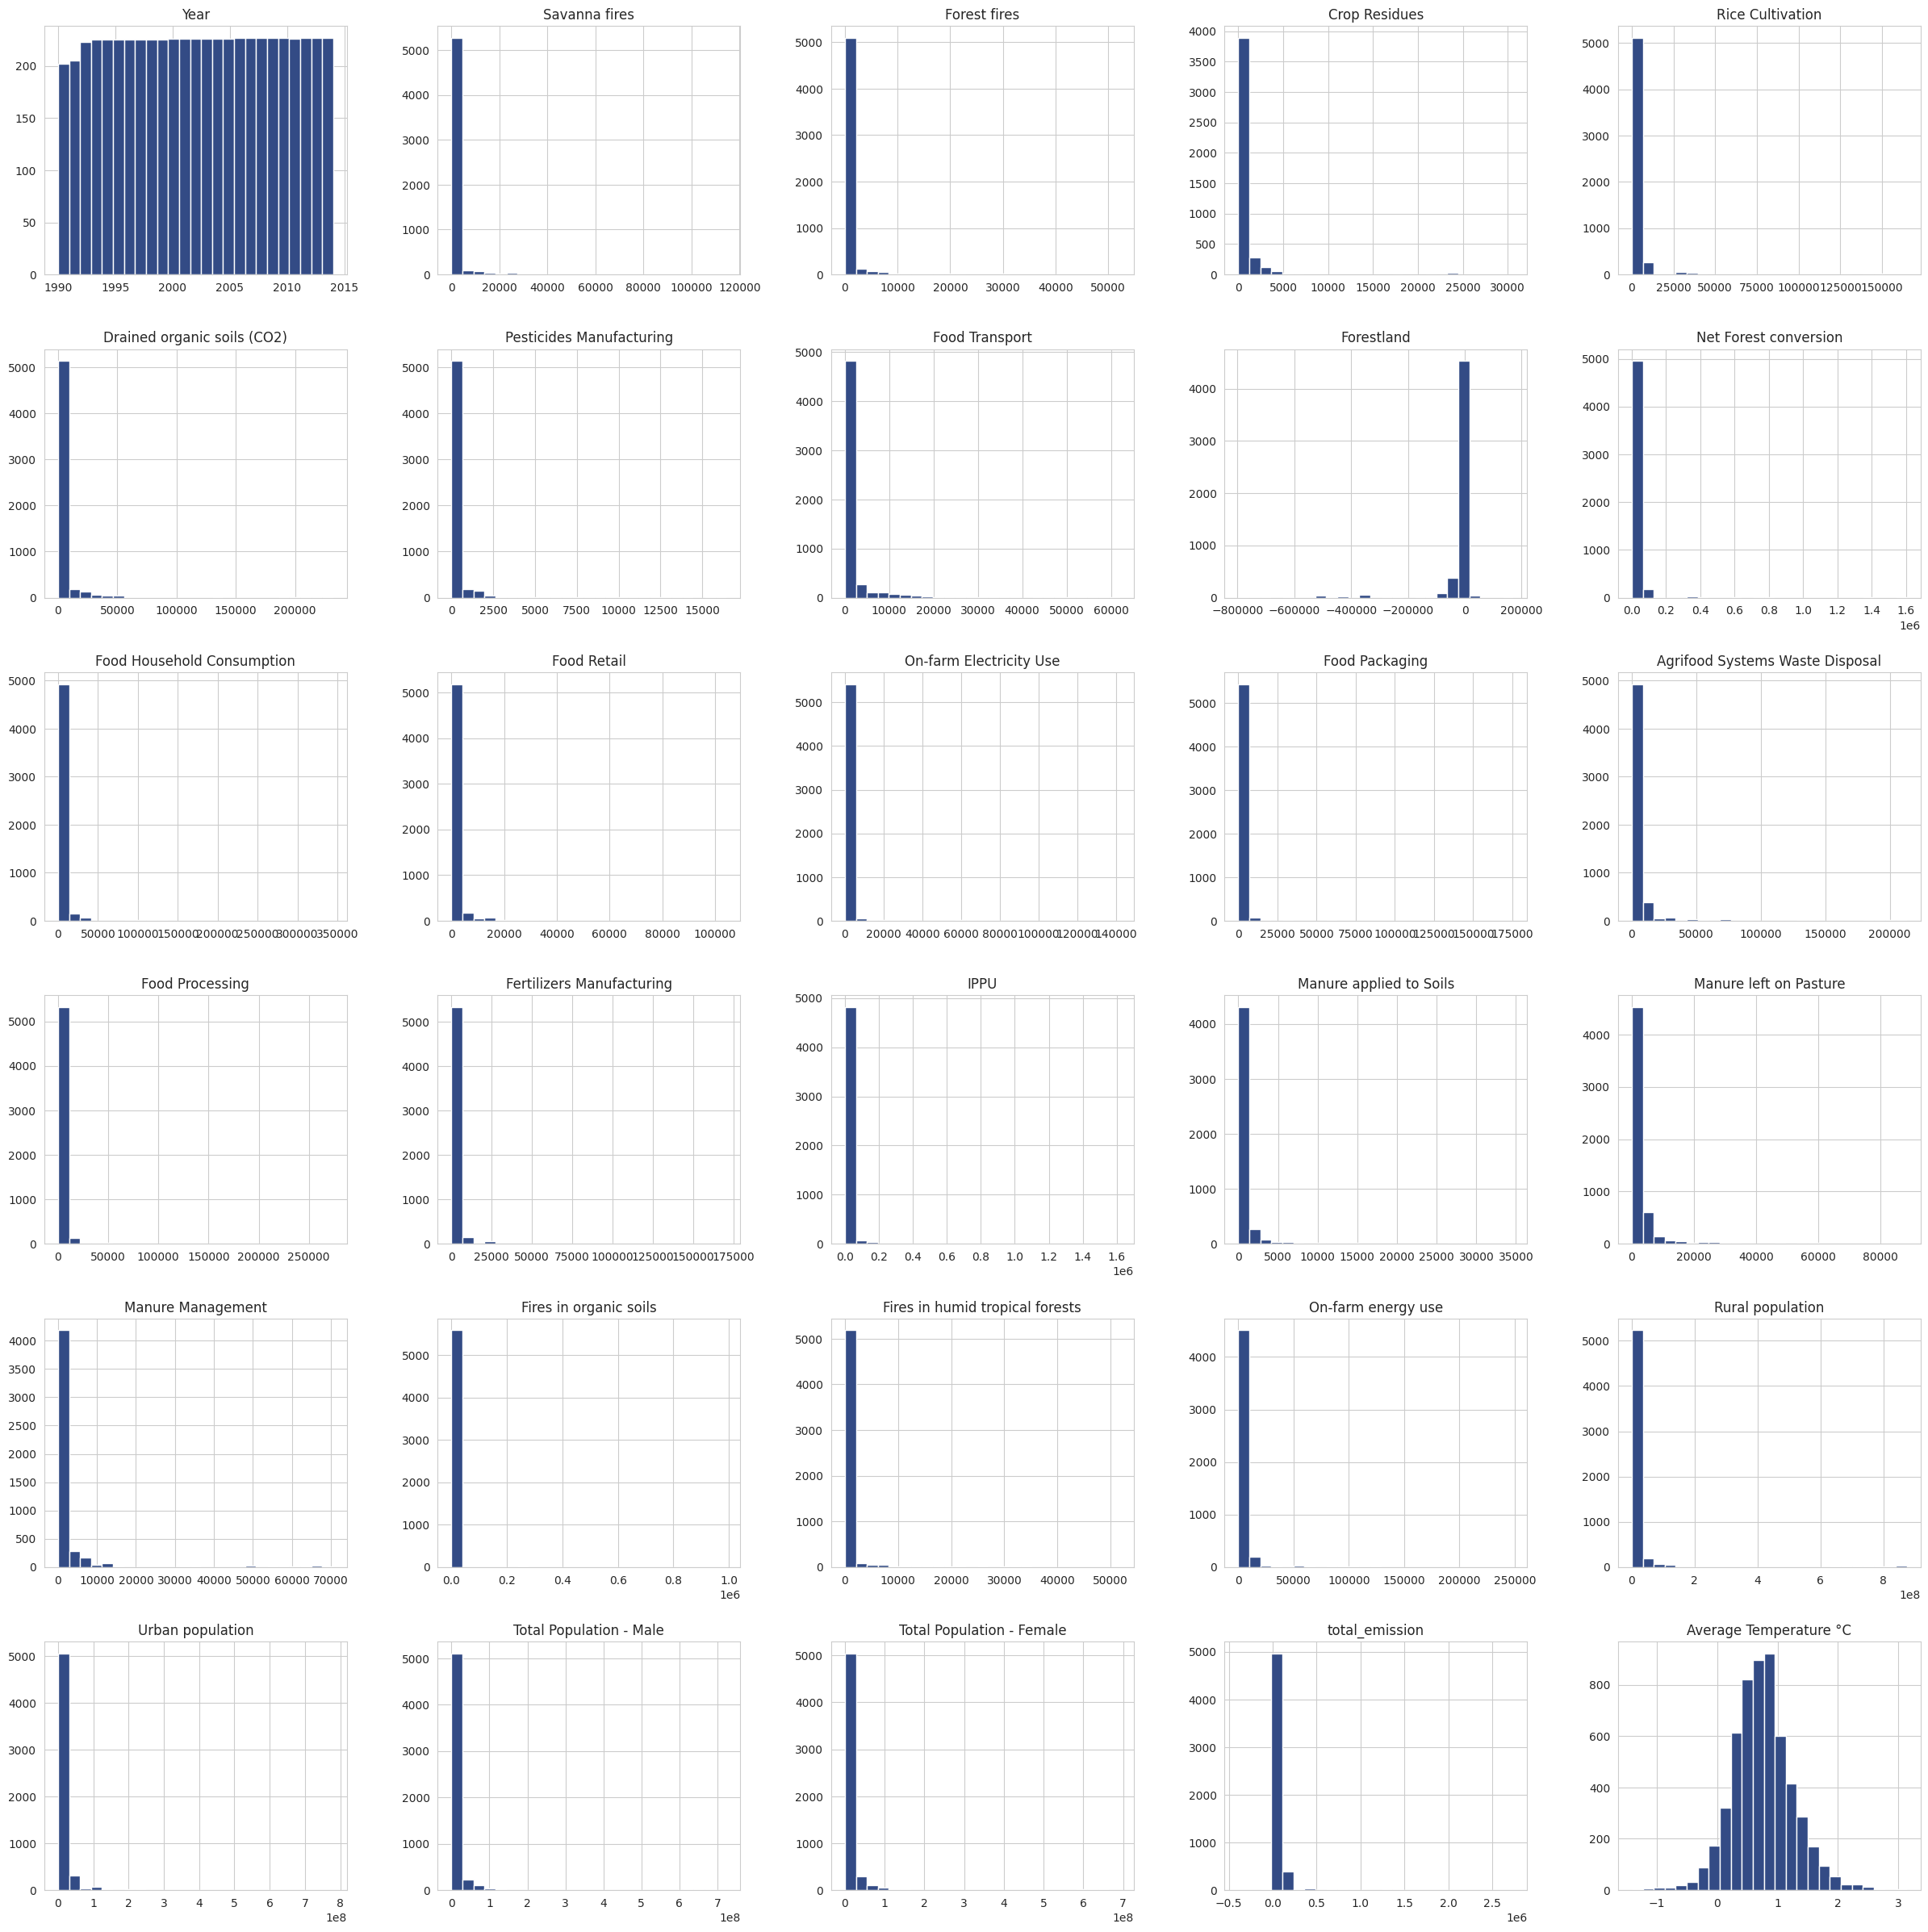

In [ ]:
agri_data_eda.hist(figsize=(30, 30), color="#334B85", bins=25)
plt.show()

We find that:
1. Nearly all numerical features are skewed heavily towards the right.
2. The population can have values of 0.
3. `Forestland` is a sink, ie. it has negative values


In [ ]:
corr = agri_data_eda.corr(numeric_only=True)
corr['Average Temperature °C'].sort_values(ascending=False)# .plot(kind='barh', figsize=(5,10), color="#334B85")
# plt.show()

,Average Temperature °C
Average Temperature °C,1.000000
Year,0.403567
Food Transport,0.062426
Food Processing,0.056041
IPPU,0.055695
Food Retail,0.055302
Food Household Consumption,0.051052
Manure applied to Soils,0.047623
On-farm energy use,0.044468
Food Packaging,0.041230


In [ ]:
corr['total_emission'].sort_values(ascending=False)# .plot(kind='barh', figsize=(5,10), color="#334B85")

,total_emission
total_emission,1.000000
Urban population,0.879824
Agrifood Systems Waste Disposal,0.866836
Manure applied to Soils,0.824351
Food Household Consumption,0.824148
IPPU,0.811345
Food Packaging,0.806274
Crop Residues,0.805243
Total Population - Female,0.797234
Total Population - Male,0.792068


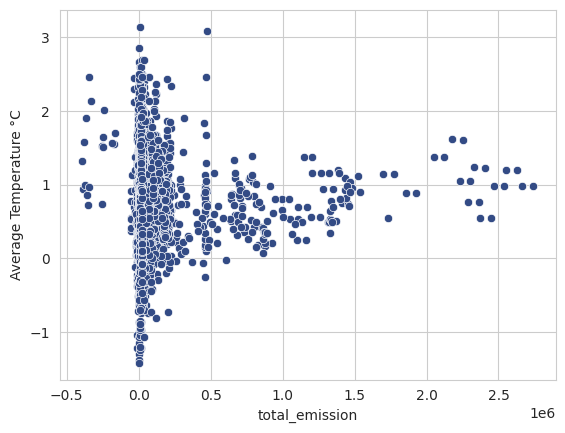

In [ ]:
sns.scatterplot(x="total_emission", y="Average Temperature °C", data=agri_data_eda, color="#334B85")
plt.show()

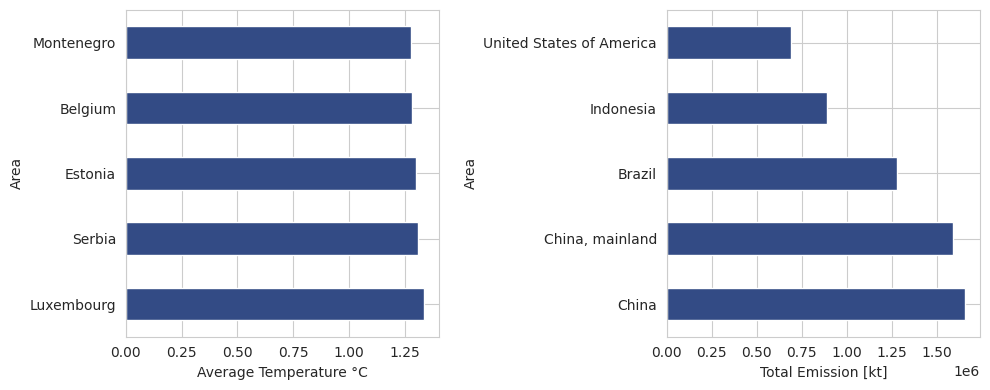

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10, 4))
mean_stats = agri_data_eda.groupby("Area").mean()
mean_stats['Average Temperature °C'].sort_values(ascending=False)[:5].plot(kind='barh',
                                                                           ax=axs[0],
                                                                           color="#334B85",
                                                                           xlabel="Average Temperature °C")
mean_stats['total_emission'].sort_values(ascending=False)[:5].plot(kind='barh',
                                                                           ax=axs[1],
                                                                           color="#334B85",
                                                                           xlabel="Total Emission [kt]")


plt.tight_layout()

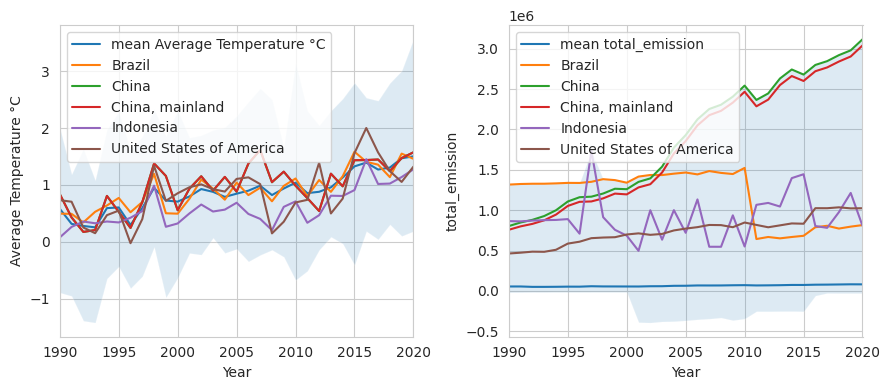

In [ ]:
# NOTE: for visualization purposes, we use the full dataset and not just the training set
fig, axs = plt.subplots(1,2, figsize=(9, 4))

idx_largest = agrifood_dataset.groupby('Area')['total_emission'].mean().sort_values(ascending=False).index[:5]
columns = ['Average Temperature °C', 'total_emission']

for ax, col in zip(axs, columns):
  temp_stats = agrifood_dataset.groupby('Year')[col].agg(['mean', 'min', 'max'])
  ax.plot(temp_stats.index, temp_stats['mean'], label='mean '+col, lw=1.5)
  ax.fill_between(temp_stats.index, temp_stats['min'], temp_stats['max'], alpha=0.15)

  agrifood_dataset[agrifood_dataset['Area'].isin(idx_largest)].pivot_table(index='Year', columns='Area', values=col).plot(ax=ax)

  ax.set_ylabel(col)
  ax.set_xlim(min(temp_stats.index), max(temp_stats.index))
  ax.legend(loc='upper left')
plt.tight_layout()

# Preparing the Data


In [ ]:
train_sort = train_set.sort_values('Year').reset_index(drop=True) # sort the training data by year.
train_sort.head()

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,Net Forest conversion,Food Household Consumption,Food Retail,On-farm Electricity Use,Food Packaging,Agrifood Systems Waste Disposal,Food Processing,Fertilizers Manufacturing,IPPU,Manure applied to Soils,Manure left on Pasture,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,205.6077,686.000000,0.0000,11.807483,63.1152,-2388.8030,0.0000,79.0851,109.6446,14.266600,67.631366,691.7888,252.214190,11.997000,209.9778,260.1431,1590.531900,319.1763,0.0,0.0000,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,American Samoa,1990,0.0000,0.0000,NaN,926.342278,0.0000,11.481085,16.9802,-58.8991,7.9612,0.5104,8.4872,17.004663,77.393651,1.6937,94.623800,2005.792129,NaN,NaN,2148.251693,NaN,0.0,0.0000,41.4996,8962.0,38076.0,24538.0,23281.0,5299.122499,0.566500
2,Albania,1990,5.5561,7.0253,59.2391,23.520000,110.5705,2.000000,46.9645,72.8581,0.0000,16.0124,8.3013,45.210300,2.850000,444.4512,131.569124,356.491017,767.1456,196.6440,383.307100,474.6951,0.0,0.0000,320.8805,2086075.0,1195379.0,1676902.0,1618163.0,3475.291240,0.735750
3,Solomon Islands,1990,0.0016,0.0053,0.0618,1.703600,0.4596,11.481085,9.5612,3682.7816,229.0904,2.0065,11.1964,17.004663,80.607732,16.5940,209.587728,5640.299993,7.0028,2.6251,7.358200,25.7795,0.0,0.0053,10.5534,269191.0,42649.0,168581.0,155589.0,9965.767501,0.446500
4,Gibraltar,1990,0.0153,0.1519,NaN,1746.105511,0.0000,11.481085,10.0430,0.0000,0.0000,0.1064,1.6480,2.067700,77.393651,1.3734,451.196291,1946.972196,NaN,NaN,2128.603725,NaN,0.0,0.0000,9.7773,0.0,29164.0,13951.0,13366.0,6386.935459,0.926167


In [ ]:
# 1. Take out the total emissions columns since we want to look at all emission sources
agri_data = train_sort.drop(columns=['Average Temperature °C', 'total_emission'], axis=1).reset_index(drop=True)
agri_labels = train_sort[['Average Temperature °C']].copy().reset_index(drop=True)
agri_labels = agri_labels.to_numpy().ravel()

In [ ]:
# 2. Cleaning and scaling the data
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, TargetEncoder

## For categories:
cat_pipeline = make_pipeline(
        SimpleImputer(strategy='constant', fill_value='none'), # This shouldn't be running. It's just as a just in case
        TargetEncoder() # encodes shrunk estimate of the average target values belonging to categories and reduces dimensionality
      )

## numerical pipeline
num_pipeline = make_pipeline(
        SimpleImputer(strategy='constant', fill_value=0), # Replace all null values in areas with 0
        PowerTransformer(method='yeo-johnson') # normalizes and standardardize data using Yeo-Johnson. StandardScalar is not needed
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
])

# Selecting and Training Models
Evaluating `LinearRegression` and `RandomForestRegressor`

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# Use cross_val_score to actually determine the best model. TimeSeriesSplit is used Cross Val
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

In [ ]:
tcv = TimeSeriesSplit(n_splits=5)

## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(agri_data, agri_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('powertransformer',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ea5e10c14c0>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='none',
                                                                                 strategy='constant')),
                                                                  ('targetencoder',
                                                                   TargetEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ea5e0c54590>)])),
                ('linearregression', LinearRegression())])

In [ ]:
lin_reg.score(agri_data, agri_labels) # training only - not used for assessment

0.39128550058886435

In [ ]:
lin_predictions = lin_reg.predict(agri_data)
lin_rmse = root_mean_squared_error(lin_predictions, agri_labels)
lin_rmse # training only - not used for assessment

0.3892416684795676

In [ ]:
lin_mae = mean_absolute_error(lin_predictions, agri_labels)
lin_mae # training only - not used for assessment

0.2839804995790833

In [ ]:
lin_rmses_cv = -cross_val_score(lin_reg, agri_data, agri_labels, scoring='neg_root_mean_squared_error', cv=tcv)
pd.Series(lin_rmses_cv).describe()

,0
count,5.000000
mean,0.437954
std,0.068834
min,0.335846
25%,0.410291
50%,0.452342
75%,0.474467
max,0.516826


In [ ]:
lin_maes_cv = -cross_val_score(lin_reg, agri_data, agri_labels, scoring='neg_mean_absolute_error', cv=tcv)
pd.Series(lin_maes_cv).describe()

,0
count,5.000000
mean,0.333503
std,0.045321
min,0.261693
25%,0.326249
50%,0.346183
75%,0.348773
max,0.384618


## Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(agri_data, agri_labels) # Note: RandomForestRegressor throws a DataConversionWarning for a 1d array

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('powertransformer',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ea5e10c14c0>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='none',
                                                                                 strategy='constant')),
                                                                  ('targetencoder',
                                                                   TargetEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ea5e0c54590>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
forest_predictions = forest_reg.predict(agri_data)

In [ ]:
forest_reg.score(agri_data, agri_labels)

0.8568405628639307

In [ ]:
forest_rmse = root_mean_squared_error(forest_predictions, agri_labels)
forest_rmse # training score only - not used for assessment

0.18876544371447923

In [ ]:
forest_mae = mean_absolute_error(forest_predictions, agri_labels)
forest_mae # training score only - not used for assessment

0.12460987891112911

In [ ]:
forest_rmses_cv = -cross_val_score(forest_reg, agri_data, agri_labels, scoring="neg_root_mean_squared_error", cv=tcv)
pd.Series(forest_rmses_cv).describe()

,0
count,5.000000
mean,0.473031
std,0.100087
min,0.320822
25%,0.463135
50%,0.475332
75%,0.508041
max,0.597824


In [ ]:
forest_maes_cv = -cross_val_score(forest_reg, agri_data, agri_labels, scoring="neg_mean_absolute_error", cv=tcv)
pd.Series(forest_maes_cv).describe()

,0
count,5.000000
mean,0.358366
std,0.084314
min,0.232523
25%,0.329650
50%,0.379489
75%,0.390261
max,0.459909


In [ ]:
# let's see if we can fine tune the random forests. This will take a few minutes..
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfr_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

rfr_params = {
    "random_forest__max_features": randint(1,100),
    "random_forest__n_estimators": randint(50, 200),
    "random_forest__min_samples_leaf": randint(1, 5)
}

random_search_rfr = RandomizedSearchCV(rfr_pipeline,
                                       rfr_params,
                                       scoring="neg_root_mean_squared_error",
                                       cv=tcv,
                                       n_iter=30,
                                       random_state=42)

In [ ]:
random_search_rfr.fit(agri_data, agri_labels)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('powertransformer',
                                                                                                PowerTransformer())]),
                                                                               <sklearn.compose._column_transformer.make_column_sele...
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ea5e0de0d10>,
                                        'random_forest__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ea5e0de0b00>,
                                        'random_forest__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ea5e343bda0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
rfr_score = -random_search_rfr.best_score_
rfr_score

np.float64(0.42718027081386023)

In [ ]:
rfr_model = random_search_rfr.best_estimator_ # choose final model base on the best RMSE score

In [ ]:
feature_importances = rfr_model['random_forest'].feature_importances_

In [ ]:
feature_sorted = sorted(zip(feature_importances, rfr_model['preprocessing'].get_feature_names_out()), reverse=True)
top_10_features = feature_sorted[:10]

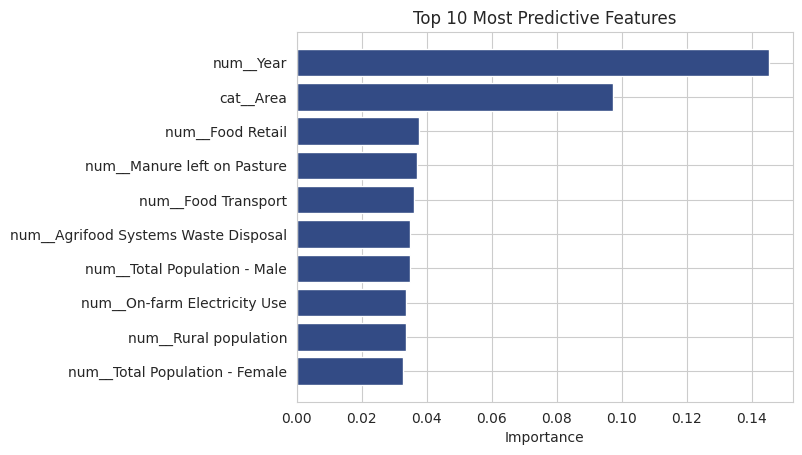

In [ ]:
values = [top_10_features[i][0] for i in range(len(top_10_features))]
labels = [top_10_features[i][1] for i in range(len(top_10_features))]
plt.barh(labels[::-1], values[::-1], color="#334B85")
plt.title("Top 10 Most Predictive Features")
plt.xlabel("Importance")
plt.savefig("most_predictive_features.jpg")
plt.show()


### Determining the most important CO2 sources
Train another dataset that consists solely of emission sources (and sinks)

In [ ]:
agri_sources = train_set.drop(columns=['Area','Average Temperature °C', 'Year', 'Urban population', 'Rural population', 'total_emission',
                                       'Total Population - Female', 'Total Population - Male'], axis=1)

co2_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

co2_search_rfr = RandomizedSearchCV(co2_pipeline,
                                      rfr_params,
                                      scoring="neg_root_mean_squared_error",
                                      cv=tcv,
                                      n_iter=20,
                                      random_state=42)


In [ ]:
co2_search_rfr.fit(agri_sources, agri_labels) # .to_numpy().ravel())
co2_model = co2_search_rfr.best_estimator_

In [ ]:
feature_importances = co2_model['random_forest'].feature_importances_

In [ ]:
feature_sorted = sorted(zip(feature_importances, co2_model['preprocessing'].get_feature_names_out()), reverse=True)
top_10_features = feature_sorted[:10]

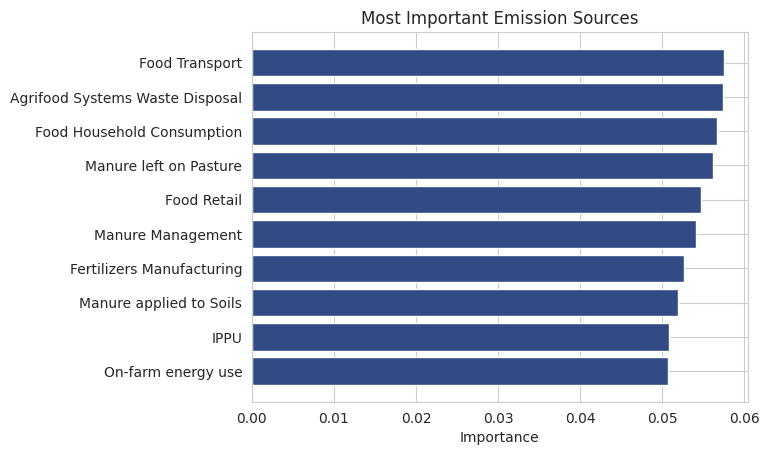

In [ ]:
values = [top_10_features[i][0] for i in range(len(top_10_features))]
labels = [top_10_features[i][1].replace('num__', '') for i in range(len(top_10_features))]
plt.barh(labels[::-1], values[::-1], color="#334B85")
plt.title("Most Important Emission Sources")
plt.xlabel("Importance")
plt.savefig("most_important_co2.jpg")
plt.show()


# Evaluating on Test Set

In [ ]:
X_test = test_set.drop(columns=['Average Temperature °C', 'total_emission'], axis=1)
y_test = test_set[['Average Temperature °C']].copy()

In [ ]:
test_prediction = rfr_model.predict(X_test)

In [ ]:
residuals = []
predictions = []
models = [('Linear Regression', lin_reg), ('Random Forest Regression', rfr_model)]
for name, model in models:
  test_prediction = model.predict(X_test)
  test_rmse = root_mean_squared_error(y_test, test_prediction)

  predictions.append(test_prediction)
  residuals.append(y_test.values.ravel() - test_prediction.ravel())
  print(name + " RMSE:", f"{test_rmse:.3g}")
  print(name + " R2:", f"{model.score(X_test, y_test):.3g}")# agri_data, agri_label


Linear Regression RMSE: 0.422
Linear Regression R2: 0.256
Random Forest Regression RMSE: 0.574
Random Forest Regression R2: -0.378


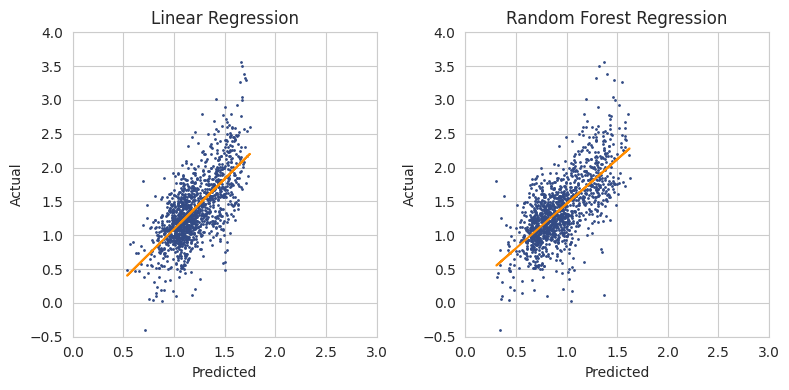

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(8,4))
for i, ax in enumerate(axs):
  ax.scatter(predictions[i], y_test.values.ravel(), s=1, color="#334B85")

  coeff = np.polyfit(predictions[i], y_test.values.ravel(), 1)
  p = np.poly1d(coeff)
  ax.plot(predictions[i], p(predictions[i]), color="darkorange")

  ax.set_title(models[i][0])
  ax.set(xlabel=('Predicted'), ylabel=('Actual'), xlim=(0.0, 3), ylim=(-0.5, 4.0))



plt.tight_layout()
plt.savefig("predicted_actual.jpg")
plt.show()


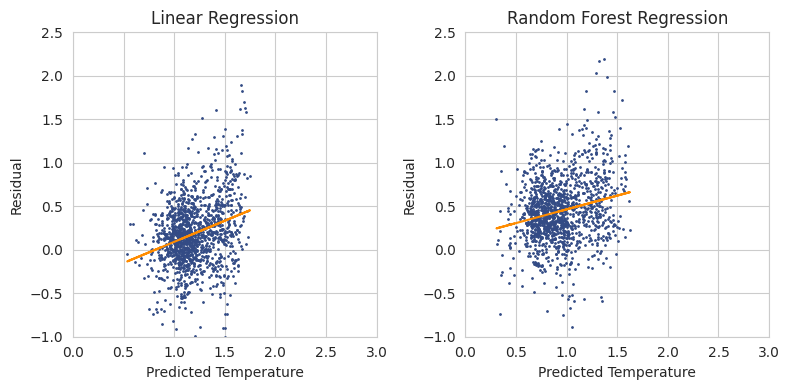

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(8,4))
for i, ax in enumerate(axs):
  ax.scatter(predictions[i], residuals[i], s=1, color="#334B85")

  coeff = np.polyfit(predictions[i], residuals[i], 1)
  p = np.poly1d(coeff)
  ax.plot(predictions[i], p(predictions[i]), color="darkorange")


  ax.set_title(models[i][0])
  ax.set(xlabel=('Predicted Temperature'), ylabel=('Residual'), xlim=(0, 3), ylim=(-1, 2.5))

plt.tight_layout()
plt.savefig("residual_data.jpg")
plt.show()


In [ ]:
import joblib
joblib.dump(rfr_model, "co2_regression_rfr.pkl")
joblib.dump(lin_reg, "co2_regression_lin.pkl")

['co2_regression_lin.pkl']

# Conclusion
Our RMSE and $R^2$ scores for the regression models are:
| Score   | Linear Regression| Random Forests Regression|
|-------- | ---------------- | -------------------------|
|  RMSE   | 0.423            |  0.572                   |
| $R^2$   | 0.251            |   -0.37                  |

Between the two models, the linear regression model has a much stronger predictive utility than the random forests regression model (RFR). In particular, the RFR model performs significantly worse than mere predicting the mean, and shouldn't be used as a forecasting as is. Comparing the plots of the predicted vs actual data and the residuals, we find that both models underpredict higher temperature changes. This can be explained by us splitting our training and testing data by year - this means that our models are insufficient at forecasting the temperature changes due to the accelerating rate of global warming, with the RFR model being particularly bad at extrapolating the temperature from recent years. A more accurate and predictive measurement would likely take into account the mean latitude and longitude of each Area and potentially the current amount of greenhouse gasses in the environment.

The most important features are predicting the temperature change are the year (which is likely reflective of current greenhouse gas emissions) and the geographic Area. Food retail and leftover manure were determined to be the most important emission sources in terms of determining the temperature change.

# ARIMA
Exploratory/just for fun and to see how a time-series model compares to the linear/logistic regression. Because ARIMA is meant for univariate models, we're restricting ourselves to just the 5 largest areas and predicting the temperature. To better forecast the temperature, we are feeding the `total_emission` as an exogenous variable.  

In [ ]:
import pmdarima as pm
from pmdarima.model_selection import SlidingWindowForecastCV, cross_val_score as cross_val_score_ar

In [ ]:
# So let's try this out on the largest area (China)
agri_0 = train_sort[train_sort['Area'] == idx_largest[0]]
agri_l0 = agri_labels[agri_0.index.values]

X = PowerTransformer(method='yeo-johnson').fit_transform(pd.DataFrame(agri_0['total_emission']))

In [ ]:
model_0 = pm.auto_arima(y=agri_l0, X=agri_0['total_emission'].to_numpy().reshape(-1,1), m=1)
model_0

ARIMA(order=(0, 0, 1), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [ ]:
m0_predictions = model_0.predict_in_sample(agri_0['total_emission'].to_numpy().reshape(-1, 1))
root_mean_squared_error(m0_predictions, agri_l0)

0.31541991777372247

In [ ]:
m0_predictions = model_0.predict_in_sample(agri_0['total_emission'].to_numpy().reshape(-1, 1))
mean_absolute_error(m0_predictions, agri_l0)

0.28131123169903977

To try this out on our test sets:

In [ ]:
ar_models = []
for i, idx in enumerate(idx_largest):
  agri_train = train_sort[train_sort['Area'] == idx]
  train_temps = agri_labels[agri_train.index.values]
  ar_models.append(pm.auto_arima(y=train_temps, X=agri_train['total_emission'].to_numpy().reshape(-1,1), m=1))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


In [ ]:
temp_forecasts = []
actual_temps = []
arima_rmses = []
for idx, model in zip(idx_largest, ar_models):
  agri_test = test_set[test_set['Area'] == idx]
  future_temps = test_set['Average Temperature °C'][agri_test.index.values]

  forecast = model.predict(len(future_temps), X=agri_test['total_emission'].to_numpy().reshape(-1,1))
  arima_rmse = root_mean_squared_error(future_temps, forecast)

  temp_forecasts.append(forecast)
  arima_rmses.append(arima_rmse)
  actual_temps.append(future_temps)

Text(0, 0.5, 'Average Temperature °C')

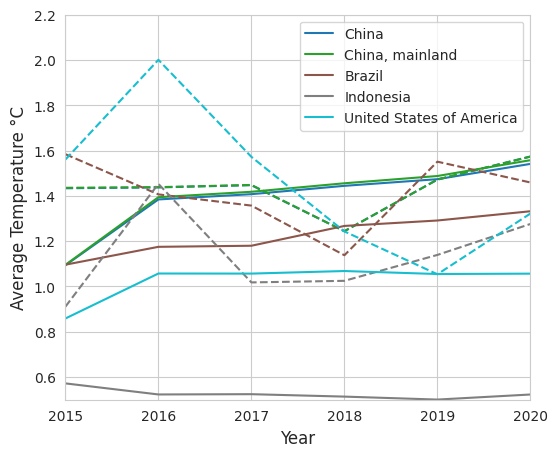

In [ ]:
plt.figure(figsize=(6,5))
color_map = plt.get_cmap('tab10')
coloring = color_map(np.linspace(0, 1, len(temp_forecasts)))

years =  np.unique(test_set['Year'].values)
for i, forecast in enumerate(temp_forecasts):
    plt.plot(years, forecast, label=idx_largest[i], color=coloring[i])
    plt.plot(years, actual_temps[i], linestyle='dashed', color=coloring[i]) # , label=idx_largest[i])


plt.legend(loc='upper right')
plt.ylim(0.5, 2.2)
plt.xlim(2015, 2020)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature °C', fontsize=12)

In [ ]:
pd.Series(arima_rmses, index=idx_largest)

,0
Area,
China,0.163930
"China, mainland",0.165256
Brazil,0.265650
Indonesia,0.640253
United States of America,0.539959


The forecast is good at predicting temperature trends, particularly when emissions are high. However, actual changes in temperature are more complicated than current models.

